<a href="https://colab.research.google.com/github/odemircse/NetworkAnalysis/blob/main/02_a_AIPA_EN_AI_in_Education_Policy_Document_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install necessary libraries
!pip install -q spacy pyvis wordcloud

# Download the large English language model from spaCy (needed for good word vectors)
import spacy.cli
spacy.cli.download("en_core_web_lg")
from google.colab import files

# This will prompt you to upload a file from your computer
uploaded = files.upload()

# Print the names of the uploaded files
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Saving 02.a. AIPA EN. AI in Education Policy Document (1).txt to 02.a. AIPA EN. AI in Education Policy Document (1).txt
User uploaded file "02.a. AIPA EN. AI in Education Policy Document (1).txt" with length 95678 bytes


                Word  Count
0                 ai    439
1          education    194
2            student    191
3           learning    109
4         technology    100
5               data     86
6            teacher     66
7             policy     52
8                use     51
9        development     51
10            system     49
11             skill     45
12              need     43
13              tool     40
14             field     38
15          language     36
16           process     36
17       application     34
18       opportunity     33
19          training     30
20  higher education     30
21       information     28
22              role     28
23          educator     27
24           machine     27
25          document     26
26              area     26
27            school     25
28          research     24
29           content     24
30           country     23
31             issue     23
32          strategy     23
33        experience     22
34     communication

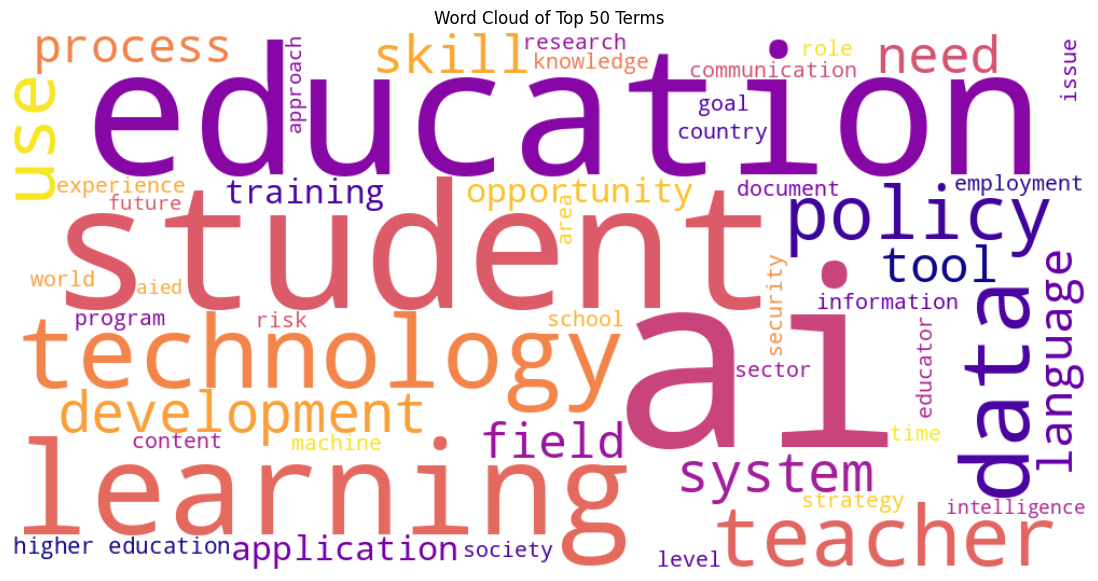

[]


In [ ]:
import spacy
from spacy.matcher import PhraseMatcher
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd


# 1. Load spaCy model
nlp = spacy.load("en_core_web_lg")

# The path to the text file
file_path = "/content/02.a. AIPA EN. AI in Education Policy Document (1).txt"

# Read the text from the file
try:
    # Try reading with latin-1 encoding first
    with open(file_path, 'r', encoding='latin-1') as f:
        text = f.read()
except UnicodeDecodeError:
    # If latin-1 fails, try another common encoding like cp1252
    try:
        with open(file_path, 'r', encoding='cp1252') as f:
            text = f.read()
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found. Please run Cell 2 or 3 first.")
        text = ""
    except Exception as e:
        print(f"An unexpected error occurred while reading the file with cp1252: {e}")
        text = ""
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please run Cell 2 or 3 first.")
    text = ""
except Exception as e:
    print(f"An unexpected error occurred while reading the file with latin-1: {e}")
    text = ""

# 🧼 Temizlik filtresi
import unicodedata
import re

# 1. Hedefli düzeltme
text = text.replace("studentsõ", "students")

# 2. Yaygın bozuk karakter düzeltmeleri
replacements = {
    "õ": "'", "â€™": "'", "â€“": "-", "â€œ": '"', "â€": '"',
    "Ã¶": "ö", "Ã¼": "ü", "Ã§": "ç", "ÅŸ": "ş", "Ä±": "ı",
    "Ã‡": "Ç", "Ä°": "İ", "Åž": "Ş", "Ã–": "Ö", "Ãœ": "Ü", "Ã": "a"
}
for wrong, correct in replacements.items():
    text = text.replace(wrong, correct)

# 3. Unicode normalize
text = unicodedata.normalize("NFC", text)

# 4. Garip karakterli kelimeleri temizle
text = ' '.join([
    word for word in text.split()
    if all((ord(c) < 128 or c in 'çÇğĞöÖşŞüÜıİ') for c in word)
])

# 5. Fazla boşlukları temizle
text = re.sub(r'\s+', ' ', text).strip()

#Initialize doc
if text:
  doc = nlp(text)

# 2. Concept map for grouping
concept_map = {
    "learning & teaching": ["Learning & Teaching", "Teaching & Learning", "learning and teaching", "teaching and learning"],
    "data": ["Datum", "Data"],
    "higher education": ["Higher Education", "University"],
    "critical thinking":["Critical Thinking"],
    "cognitive skills": ["Cognitive Skills"],
    "research and development": ["Research and Development","r&d"],
    "competency": ["Competence Framework"],
    "high school":["High School"],
    "generative ai":["generative ai"]
}


# 3. Build matcher
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
for label, phrases in concept_map.items():
    patterns = [nlp.make_doc(phrase) for phrase in phrases]
    matcher.add(label, patterns)


# 4. Merge matches into single tokens with normalized lemmas
matches = matcher(doc)
spans = [doc[start:end] for _, start, end in matches]
with doc.retokenize() as retokenizer:
    for span in spans:
        label = next((key for key, val in concept_map.items() if span.text.lower() in [v.lower() for v in val]), None)
        if label:
            retokenizer.merge(span, attrs={"LEMMA": label})

# 5. Extract nouns and proper nouns, exclude stopwords/punctuations
excluded_words = {
        "develop", "create", "provide", "ensure", "prepare", "establish", "provide", "prepare", "determine", "learn", "develop", "apply", "educate", "communicate", "mef"
    }
filtered_words = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop
    and not token.is_punct
    and not token.is_space
    and token.pos_ in {"NOUN", "PROPN"}
    and token.lemma_.lower() not in excluded_words
]

# 6. Get top 50 frequent terms
word_counts = Counter(filtered_words)
most_common = word_counts.most_common(50)
df = pd.DataFrame(most_common, columns=["Word", "Count"])
print(df)

# 7. Generate word cloud  - Burada colormap için viridis yerine turbo,rocket, plasma, magma kullanılabilir
wc = WordCloud(width=1000, height=500, background_color="white", colormap="plasma")
wc.generate_from_frequencies(dict(most_common))

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Top 50 Terms")
plt.show()

from collections import Counter
words = text.split()
weird_words = [word for word in words if any(ord(c) > 127 for c in word)]
print(Counter(weird_words).most_common(10))


/tmp/ipython-input-3748623856.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Spectral", NUM_COLOR_BINS)  # Discrete colors


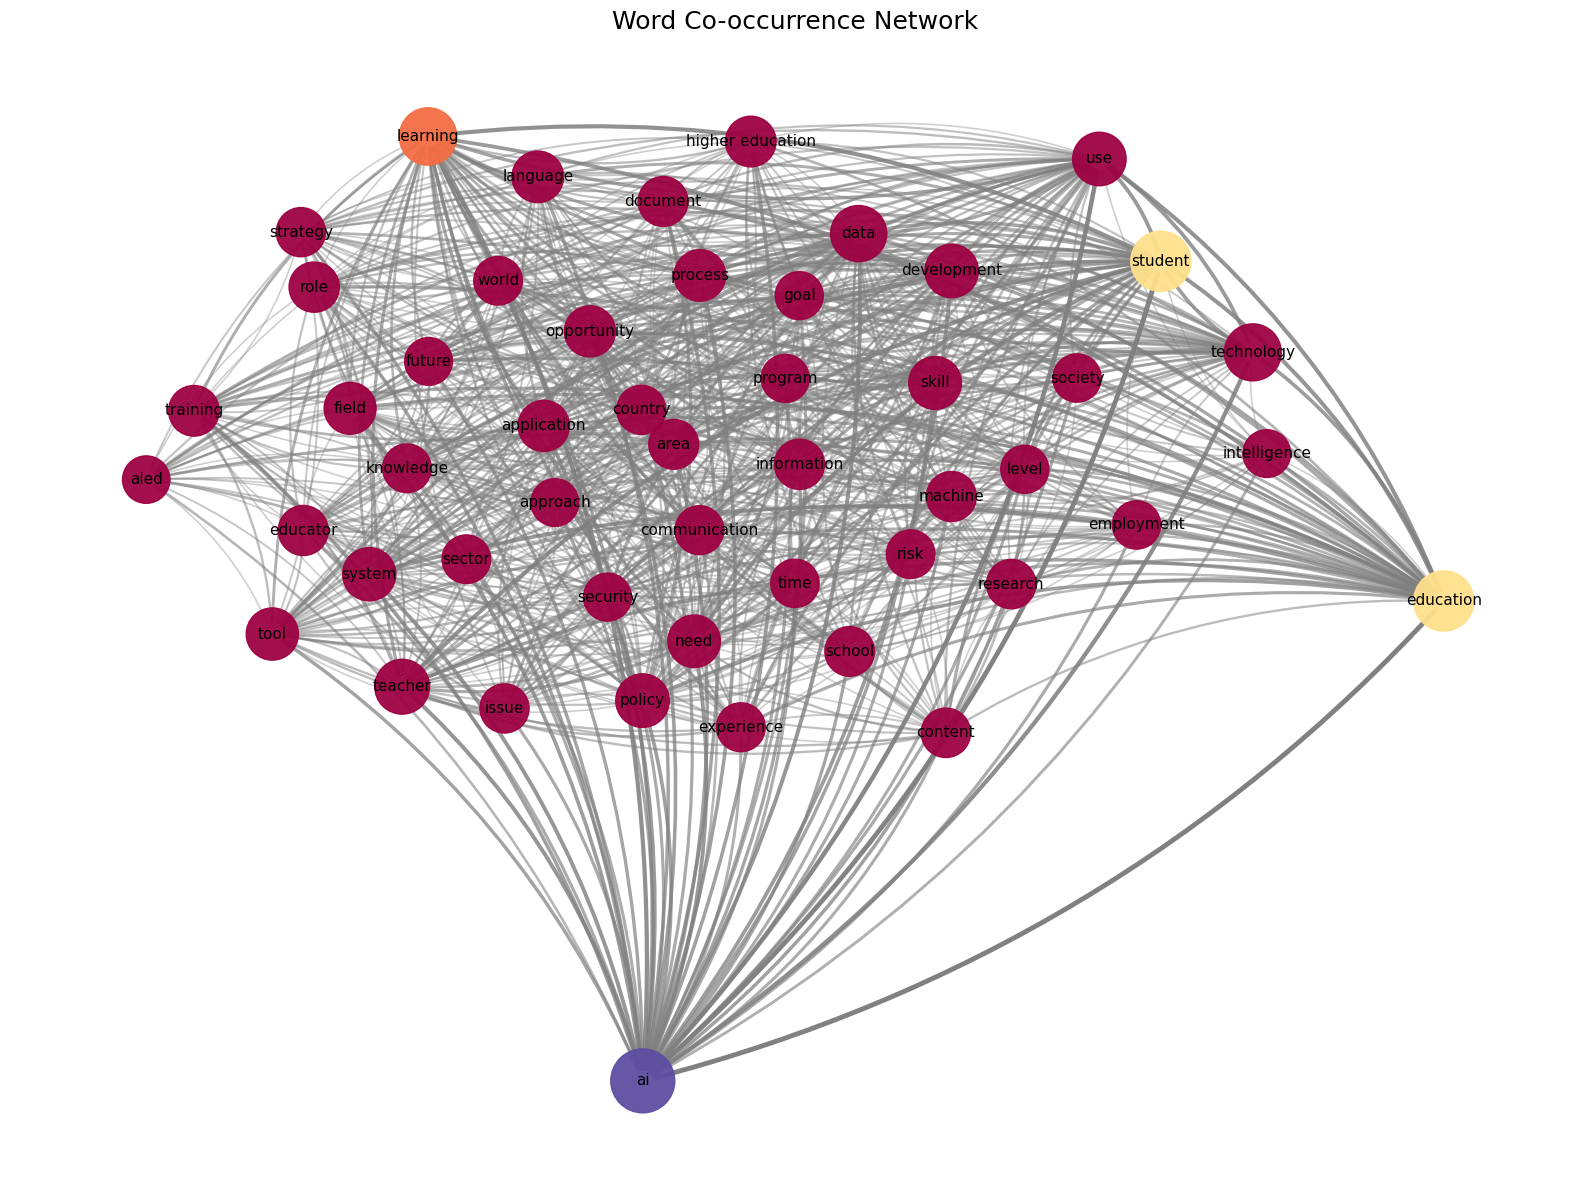

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize, ListedColormap, to_hex
from matplotlib import cm
from pyvis.network import Network
from IPython.core.display import display, HTML
from itertools import combinations
from collections import defaultdict
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# --- Parameters ---
EDGE_THRESHOLD = 1  # Lowered to allow more connections
NUM_COLOR_BINS = 6  # Number of distinct color steps

# --- Colormap: Spectral segmented into bins ---
cmap = cm.get_cmap("Spectral", NUM_COLOR_BINS)  # Discrete colors

# --- Frequency dictionary ---
word_counts_dict = dict(most_common)
counts = list(word_counts_dict.values())
top_words = [word for word, count in most_common]
norm = Normalize(vmin=min(counts), vmax=max(counts))

# --- Build the graph ---
G = nx.Graph()

# Add nodes with binned color mapping
for word, count in most_common:
    bin_index = int(norm(count) * (NUM_COLOR_BINS - 1))
    hex_color = to_hex(cmap(bin_index))
    G.add_node(word, size=300 + np.log(count + 1) * 300, color=hex_color)


# --- Count co-occurrences of top words ---
edge_counts_words = defaultdict(int)
if text:
    for sentence in doc.sents:
        words_in_sentence = {
            token.lemma_.lower() for token in sentence if token.lemma_.lower() in top_words
        }
        if len(words_in_sentence) > 1:
            for pair in combinations(sorted(words_in_sentence), 2):
                edge_counts_words[pair] += 1


# Add nodes with binned color mapping
for word, count in most_common:
    bin_index = int(norm(count) * (NUM_COLOR_BINS - 1))
    hex_color = to_hex(cmap(bin_index))
    G.add_node(word, size=300 + np.log(count + 1) * 300, color=hex_color)

top_words = [word for word, count in most_common]
word_counts_dict = dict(most_common)
counts = list(word_counts_dict.values())

# Add edges with co-occurrence weights
for (w1, w2), cooc in edge_counts_words.items():
    if cooc >= EDGE_THRESHOLD:
        G.add_edge(w1, w2, weight=0.5 + np.log(cooc + 1))


# --- Use Kamada-Kawai layout with increased scale ---
plt.figure(figsize=(16, 12))  # Bigger canvas
pos = nx.kamada_kawai_layout(G, scale=5)  # More space between nodes

# --- Prepare draw parameters ---
node_sizes = [G.nodes[n]['size'] for n in G.nodes]
node_colors = [G.nodes[n]['color'] for n in G.nodes]
edge_widths = [G[u][v]['weight'] for u, v in G.edges]



# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.95)

# Improved edge drawing (like World Economic Forum map)
edge_weights = [G[u][v]['weight'] for u, v in G.edges]
max_weight = max(edge_weights)
edge_widths = [0.5 + 3 * (w / max_weight) for w in edge_weights]
edge_alphas = [0.2 + 0.8 * (w / max_weight) for w in edge_weights]

for (edge, width, alpha) in zip(G.edges, edge_widths, edge_alphas):
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[edge],
        width=width,
        edge_color='gray',
        alpha=alpha,
        connectionstyle='arc3,rad=0.15',
        arrows=True  # ✅ Forces FancyArrowPatch backend
    )

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=11, font_color='black')

plt.title("Word Co-occurrence Network", fontsize=18)
plt.axis('off')
plt.tight_layout()
plt.savefig("word_network_curved_edges.svg", format="svg")
plt.show()


In [ ]:
pip install adjustText


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm, colors
import pandas as pd
import community as community_louvain  # pip install python-louvain if missing

# --- Quantile binning into 5 color groups ---
counts = pd.Series([word_counts_dict[n] for n in G.nodes()])
quantile_bins = pd.qcut(counts, 15, labels=False, duplicates='drop')


from matplotlib import colormaps
from matplotlib.colors import ListedColormap

# Sample 15 equally spaced values from the continuous 'Spectral'
spectral = colormaps['Spectral']
discrete_colors = [spectral(i / 14) for i in range(15)]  # 15 bins → divide by (n-1)
cmap = ListedColormap(discrete_colors)

quantile_node_colors = [
    colors.to_hex(cmap(14 - q)) for q in quantile_bins
]

ai düğümünün yeni pozisyonu: (np.float64(-0.11143946339296303), np.float64(0.0320901047786307))
sector düğümünün yeni pozisyonu: (np.float64(-0.6177717296350054), np.float64(0.06540728289753775))
training düğümünün yeni pozisyonu: (np.float64(-0.20682259907118866), np.float64(-0.03358570526310663))
technology düğümünün eski pozisyonu: [-0.04206949  0.07870853]
technology düğümünün yeni pozisyonu: (np.float64(0.047930508567678276), np.float64(0.20870853393893452))
system düğümünün eski pozisyonu: [ 0.29926969 -0.08711306]
system düğümünün yeni pozisyonu: (np.float64(0.20926969454680247), np.float64(-0.2571130577533336))


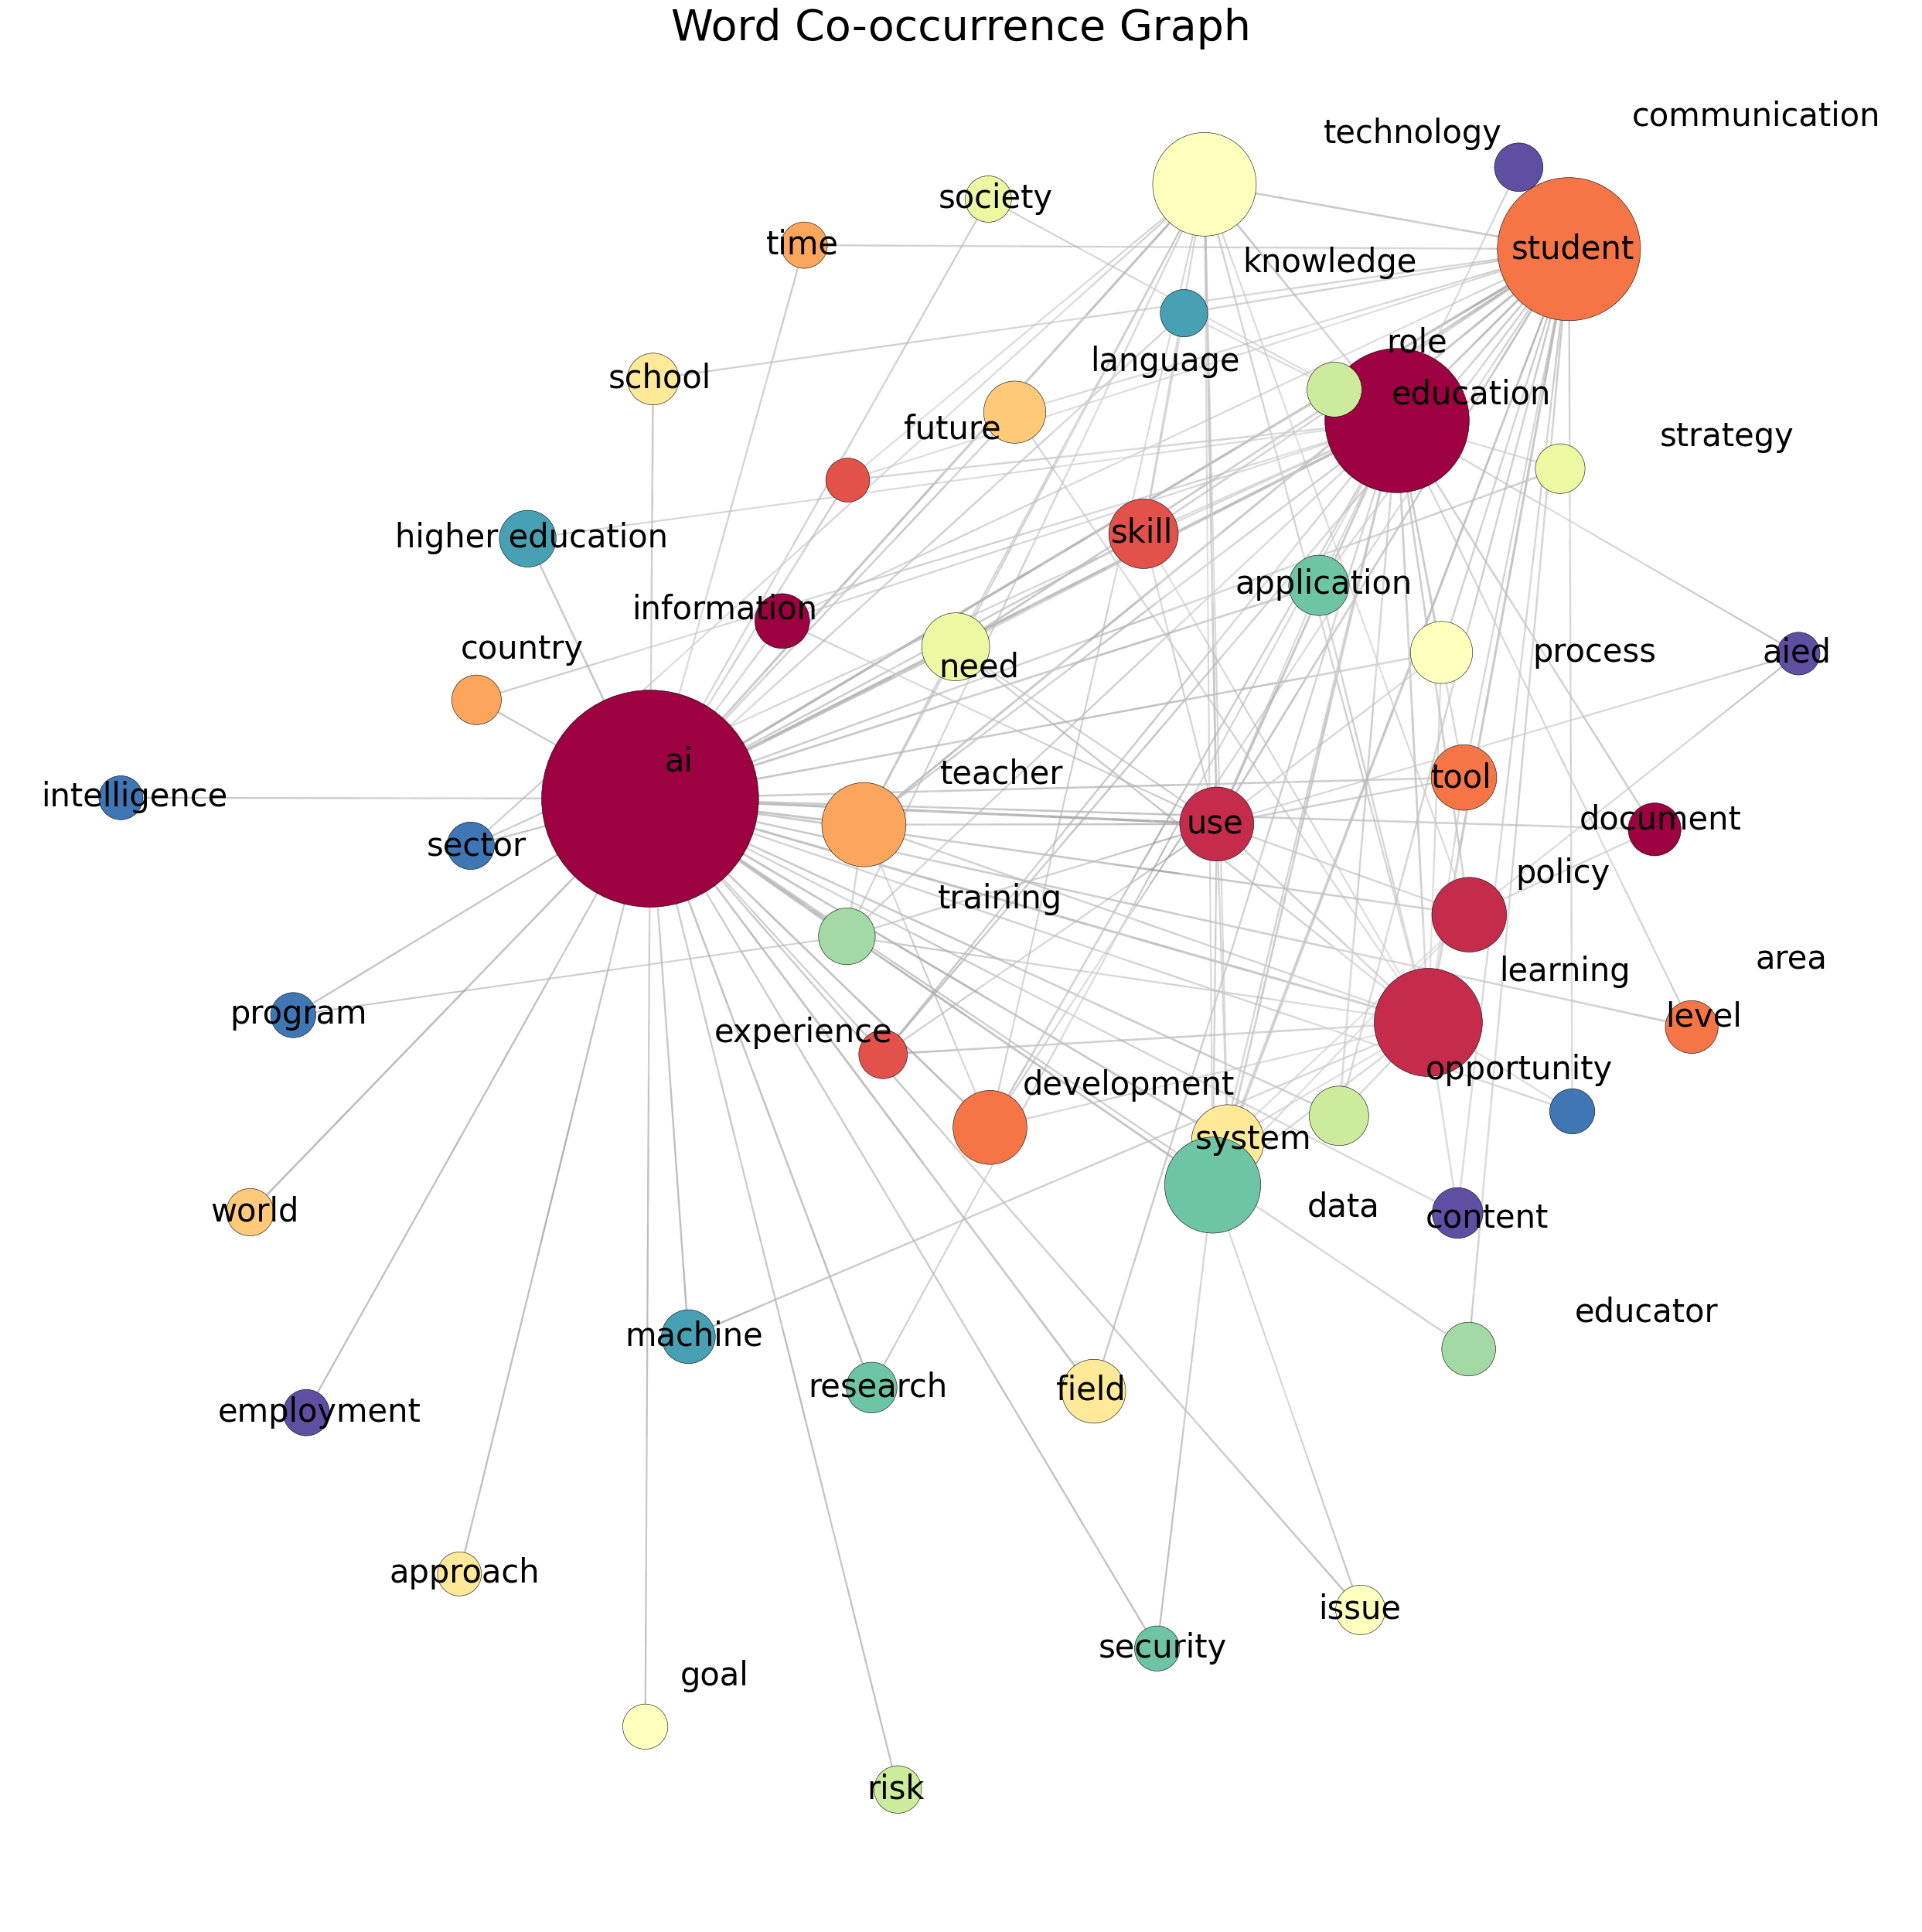

In [ ]:
!pip install adjustText
from adjustText import adjust_text
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from adjustText import adjust_text

# --- Threshold filtering ---
THRESHOLD = 2.5
G_filtered = nx.Graph()
for u, v, d in G.edges(data=True):
    if d['weight'] >= THRESHOLD:
        G_filtered.add_edge(u, v, **d)
G_filtered.add_nodes_from(G.nodes(data=True))  # retain node attributes

# --- Layout using Kamada-Kawai (for less overlap) ---
#pos = nx.kamada_kawai_layout(G_filtered)
pos = nx.spring_layout(
    G_filtered,
    seed=85,
    k=5,          # more spacing between nodes
   iterations=500  # more precision
)


target_node_3 = 'ai'
move_up_amount = 0.08  # Bu değeri ihtiyacınıza göre ayarlayın
move_right_amount = -0.06
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    new_y = current_y + move_up_amount
    new_x = current_x + move_right_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")



target_node_3 = 'sector'
move_up_amount = 0.03  # Bu değeri ihtiyacınıza göre ayarlayın
move_right_amount = -0.1
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    new_y = current_y + move_up_amount
    new_x = current_x + move_right_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")

target_node_3 = 'training'
move_up_amount = 0.02  # Bu değeri ihtiyacınıza göre ayarlayın
move_right_amount = 0.13
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    new_y = current_y + move_up_amount
    new_x = current_x + move_right_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")

target_node_3 = 'technology'
move_up_amount = 0.13  # Bu değeri ihtiyacınıza göre ayarlayın
move_right_amount = 0.09
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    print(f"{target_node_3} düğümünün eski pozisyonu: {pos[target_node_3]}")
    new_y = current_y + move_up_amount
    new_x = current_x + move_right_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")


target_node_3 = 'system'
move_up_amount = -0.17  # Bu değeri ihtiyacınıza göre ayarlayın
move_right_amount = -0.09
if target_node_3 in pos:
    current_x, current_y = pos[target_node_3]
    print(f"{target_node_3} düğümünün eski pozisyonu: {pos[target_node_3]}")
    new_y = current_y + move_up_amount
    new_x = current_x + move_right_amount
    pos[target_node_3] = (new_x, new_y)
    print(f"{target_node_3} düğümünün yeni pozisyonu: {pos[target_node_3]}")


# --- 3D node drawing ---
def draw_3d_nodes(ax, pos, node_sizes, node_colors):
    for (node, (x, y), size, color) in zip(G_filtered.nodes(), pos.values(), node_sizes, node_colors):
        r = np.sqrt(size) / 500
        circle = plt.Circle((x, y), r, color=color, ec='black', lw=0.4, zorder=2)
        ax.add_patch(circle)
        #highlight = plt.Circle((x - r / 3, y + r / 3), r / 2.5, color='white', alpha=0.3, zorder=3)
        #ax.add_patch(highlight)

def draw_halos(ax, pos, nodes, color='lightgray', alpha=0.5, size=1000):
    for node in nodes:
        if node in pos:
            x, y = pos[node]
            halo = plt.Circle((x, y), np.sqrt(size) / 100, color=color, alpha=alpha, zorder=1)
            ax.add_patch(halo)

# --- Node size ---
node_sizes = [ word_counts_dict[n] *8 for n in G_filtered.nodes()]

# --- Central nodes logic ---
central_nodes = sorted(word_counts_dict.items(), key=lambda x: x[1], reverse=True)[:5]
central_node_names = [n for n, _ in central_nodes]

# Push central nodes outward from graph center
center_x = np.mean([x for x, y in pos.values()])
center_y = np.mean([y for x, y in pos.values()])
for node in central_node_names:
    if node in pos:
        x, y = pos[node]
        dx = x - center_x
        dy = y - center_y
        factor = 2.8
        pos[node] = (x + dx * factor, y + dy * factor)

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(25, 25))
ax.set_aspect('equal')
ax.axis('off')

# --- Edges ---
edge_weights = [G_filtered[u][v]['weight'] for u, v in G_filtered.edges]
max_weight = max(edge_weights)
edge_widths = [0.5 + 2 * (w / max_weight) for w in edge_weights]
edge_alphas = [0.2 + 0.8 * (w / max_weight) for w in edge_weights]

for (edge, width, alpha) in zip(G_filtered.edges, edge_widths, edge_alphas):
    nx.draw_networkx_edges(G_filtered, pos, edgelist=[edge], width=width,
                           edge_color='gray', alpha=alpha, ax=ax)

# --- Halos ---
draw_halos(ax, pos,  G_filtered.nodes(),color='white', alpha=0.1)

# --- 3D-look Nodes ---
draw_3d_nodes(ax, pos, node_sizes, quantile_node_colors)

# --- Smart labels using adjustText ---
texts = []
for node, (x, y) in pos.items():
    texts.append(ax.text(x, y, node, fontsize=30, ha='center', va='bottom'))

#for node, (x, y) in pos.items():
#    texts.append(ax.text(x, y + 0.03, node, fontsize=30, ha='center', va='bottom'))
adjust_text(texts, ax=ax, expand_text=(1.2, 1.3), force_text=0.8,add_objects=None)


# Etiketleri çakışmadan ayarla
adjust_text(
    texts,
    ax=ax,
    expand_text=(1.5, 1.5),
    force_text=2.0)



# --- Title & Save ---
plt.title("Word Co-occurrence Graph", fontsize=40)
plt.tight_layout()
plt.savefig("word_network_kamada_adjusted.png", dpi=100)
plt.show()



In [ ]:
# --- Calculate Semantic Similarity between Top Words ---
print("\n--- Semantic Similarity Analysis ---")
similarity_pairs = []
top_word_docs = [nlp(word) for word, count in most_common]

if len(top_word_docs) > 1:
    for doc1, doc2 in combinations(top_word_docs, 2):
        # Ensure words have vectors before comparing
        if doc1.has_vector and doc2.has_vector:
            similarity = doc1.similarity(doc2)
            similarity_pairs.append((doc1.text, doc2.text, similarity))

# Create a DataFrame for easy sorting
similarity_df = pd.DataFrame(similarity_pairs, columns=['Word 1', 'Word 2', 'Similarity'])

# --- Display Most CLOSE Words ---
print("\n--- Top 10 Most Semantically CLOSE Word Pairs ---")
most_similar_df = similarity_df.sort_values(by='Similarity', ascending=False).head(10)
print(most_similar_df.to_string(index=False))

# --- Display Most DISTANT Words ---
print("\n--- Top 10 Most Semantically DISTANT Word Pairs ---")
# We filter out scores of 0 which can mean out-of-vocabulary
most_distant_df = similarity_df[similarity_df['Similarity'] > 0].sort_values(by='Similarity', ascending=True).head(10)
print(most_distant_df.to_string(index=False))


--- Semantic Similarity Analysis ---

--- Top 10 Most Semantically CLOSE Word Pairs ---
   Word 1           Word 2  Similarity
education higher education    0.870285
  teacher           school    0.757835
  student          teacher    0.741736
  student           school    0.740406
education           school    0.703859
education         learning    0.699891
  teacher         educator    0.692543
 learning        knowledge    0.689210
      use             need    0.670511
 strategy         approach    0.667693

--- Top 10 Most Semantically DISTANT Word Pairs ---
Word 1      Word 2  Similarity
    ai      sector    0.000638
    ai  employment    0.016962
    ai    educator    0.031257
    ai application    0.033013
    ai  technology    0.037747
    ai    research    0.038558
    ai     process    0.045658
    ai     student    0.050071
    ai       field    0.059959
  data    educator    0.062440


In [ ]:
from collections import defaultdict
from spacy.matcher import PhraseMatcher

# --- 1. DEFINE YOUR RISKS (Case-Insensitive Matching) ---
custom_risks = [
    "AI", "Teaching", "Motivation", "Big Data", "Dependability", "Design", "Media",
    "Networks", "Mathematics", "Cybersecurity", "Writing", "Flexibility", "Social Influence",
    "Reading", "Multi-lingualism", "Curiosity", "Leadership", "Empathy", "Operations",
    "User Experience", "Creative Thinking", "Mentoring", "Programming", "Analytical Thinking",
    "Lifelong Learning", "Customer Service", "Manual Dexterity", "Precision", "Resilience",
    "Agility", "Self-awareness", "Technological Literacy", "Active Listening", "Talent Management",
    "Service Orientation", "Systems Thinking", "Resource Management", "Attention to Detail",
    "Quality Control", "Marketing", "Environmental Stewardship", "Endurance", "Global Citizenship",
    "Sensory-processing Abilities"
]

# attr='LOWER' makes the matching case-insensitive. "Debt" and "debt" will both match.
matcher = PhraseMatcher(nlp.vocab, attr='LOWER')
patterns = [nlp.make_doc(risk) for risk in custom_risks]
matcher.add("RISKS", patterns)

node_counts_risk = defaultdict(int)
edge_counts_risk = defaultdict(int)

# --- 2. PROCESS TEXT TO FIND RISK NODES AND EDGES ---
if text:
    doc = nlp(text)
    # The 'doc' object is reused from Cell 4, no need to re-process.

    matches = matcher(doc)
    # Store results in a case-normalized way
    for match_id, start, end in matches:
        node_label = doc[start:end].text.lower().title() # Normalize to Title Case
        node_counts_risk[node_label] += 1

    for sentence in doc.sents:
        sentence_risks = set()
        sentence_matches = matcher(sentence)
        for match_id, start, end in sentence_matches:
            sentence_risks.add(sentence[start:end].text.lower().title()) # Normalize

        if len(sentence_risks) > 1:
            for pair in combinations(sorted(list(sentence_risks)), 2):
                edge_counts_risk[pair] += 1

# --- 3. PREPARE DATA FOR RISK VISUALIZATION ---
nodes_data_risk = [{'id': label, 'label': label, 'size': 10 + count * 5, 'title': f'Mentions: {count}'}
                   for label, count in node_counts_risk.items()]

edges_data_risk = [{'from': pair[0], 'to': pair[1], 'width': weight * 2, 'title': f'Co-mentions: {weight}'}
                   for pair, weight in edge_counts_risk.items()]

print("\n\n--- Extracted Nodes for Specific Risk Network ---")
print(pd.DataFrame([{'Risk': n['id'], 'Importance': n['title']} for n in nodes_data_risk]))



--- Extracted Nodes for Specific Risk Network ---
                   Risk     Importance
0                    Ai  Mentions: 444
1              Teaching   Mentions: 20
2               Reading    Mentions: 2
3                Design    Mentions: 8
4               Empathy    Mentions: 2
5     Lifelong Learning    Mentions: 4
6            Leadership    Mentions: 4
7   Resource Management    Mentions: 1
8         Cybersecurity    Mentions: 3
9             Curiosity    Mentions: 1
10                Media    Mentions: 5
11          Programming    Mentions: 3
12              Writing    Mentions: 2
13           Motivation    Mentions: 2
14             Big Data    Mentions: 1
15          Mathematics   Mentions: 10
16             Networks    Mentions: 1
17     Customer Service    Mentions: 1
